# Pitch spring added mass comparison

This notebook compares one spring pitch decay test with two OrcaFlex simulations:

1. **Without added mass correction** (`aeroaddedmass.HydrodynamicInertiaY = 0`)
2. **With added mass correction** (`aeroaddedmass.HydrodynamicInertiaY = 1031`)

Both simulations are run **without viscous damping**, so the difference in the plots is caused by the added inertia correction only.


In [33]:
# ============================================================
# 1. Imports
# ============================================================
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from scipy.signal import find_peaks

import OrcFxAPI


In [34]:
# ============================================================
# 2. Paths and settings
# ============================================================
data_root = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_data\01_Rawdata")
orca_root = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_ORCA")

exp_path = data_root / "02" / "002" / "34224_03CB_02_002_001_01_Decay3.h5m"
model_path = orca_root / "Harlequin_spring_120s_aerocorrected.dat"

output_dir = Path(r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_postprocess")
plots_dir = output_dir / "plots_addedmass_compare_pitch_spring"
tables_dir = output_dir / "tables"
plots_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)

summary_excel_path = tables_dir / "pitch_spring_addedmass_compare.xlsx"

# OrcaFlex object names
vesselname = "floaters"
vesseltypename = "floatertype"
addedmass_object_name = "aeroaddedmass"

# DOF and experiment settings
construction = "spring"
dof = "pitch"
prominence = 0.2
min_initial_amp = 3.0

# Added mass cases. Only HydrodynamicInertiaY is changed for this pitch comparison.
added_mass_cases = {
    "without_added_mass_correction": {
        "plot_title": "Without added mass correction",
        "HydrodynamicMassZ": 0.0,
        "HydrodynamicInertiaX": 0.0,
        "HydrodynamicInertiaY": 0.0,
    },
    "with_added_mass_correction": {
        "plot_title": "With added mass correction",
        "HydrodynamicMassZ": 0.0,
        "HydrodynamicInertiaX": 0.0,
        "HydrodynamicInertiaY": 1506.0,
    },
}

# Plot format
TITLE_SIZE = 14
LABEL_SIZE = 12
TICK_SIZE = 10
FIGSIZE = (14, 6)
DPI = 200

print("Experiment:", exp_path)
print("Model:", model_path)
print("Plots will be saved to:", plots_dir)


Experiment: C:\Users\verav\Desktop\Studie\Afstuderen\Decay_data\01_Rawdata\02\002\34224_03CB_02_002_001_01_Decay3.h5m
Model: C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_ORCA\Harlequin_spring_120s_aerocorrected.dat
Plots will be saved to: C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_postprocess\plots_addedmass_compare_pitch_spring


In [35]:
# ============================================================
# 3. Experiment helper functions
# ============================================================
def read_decay_signals(exp_path: Path, dof: str):
    filtered_map = {
        "pitch": "CroppedSignals/PITCH (LPF: 5.0 rad*s^-1)",
        "roll": "CroppedSignals/ROLL (LPF: 5.0 rad*s^-1)",
        "heave": "CroppedSignals/Z_COG (LPF: 5.0 rad*s^-1)",
    }

    unfiltered_map = {
        "pitch": "UnfilteredSignals/PITCH (unfiltered)",
        "roll": "UnfilteredSignals/ROLL (unfiltered)",
        "heave": "UnfilteredSignals/Z_COG (unfiltered)",
    }

    with h5py.File(exp_path, "r") as f:
        t_filt = np.array(f["CroppedSignals/time"])
        z_filt = np.array(f[filtered_map[dof]])
        t = np.array(f["UnfilteredSignals/time"])
        z = np.array(f[unfiltered_map[dof]])

    return t_filt, z_filt, t, z


def find_first_zero_crossing(t, z):
    z = np.asarray(z)
    for i in range(1, len(z)):
        if z[i - 1] == 0:
            return i - 1, t[i - 1]
        if z[i - 1] * z[i] < 0:
            return i, t[i]
    raise ValueError("No zero crossing found.")


def find_initial_amplitude_from_zero_crossing(t, z, t_zero, search_window=20.0):
    mask = (t >= t_zero - search_window) & (t <= t_zero)
    if np.sum(mask) == 0:
        raise ValueError("No data found in search window for initial amplitude.")
    t_win = t[mask]
    z_win = z[mask]
    i_local = np.argmax(np.abs(z_win))
    return t_win[i_local], z_win[i_local]


def classify_extremum_type(a_value):
    return "peak" if a_value >= 0 else "trough"


def find_first_two_same_type_extrema_after_reference(t, z, t_reference, extremum_type, prominence):
    t = np.asarray(t)
    z = np.asarray(z)

    if extremum_type == "peak":
        idx_all, _ = find_peaks(z, prominence=prominence)
    elif extremum_type == "trough":
        idx_all, _ = find_peaks(-z, prominence=prominence)
    else:
        raise ValueError(f"Unknown extremum_type: {extremum_type}")

    idx_after_ref = idx_all[t[idx_all] >= t_reference]
    if len(idx_after_ref) < 2:
        raise ValueError(f"Not enough {extremum_type}s found after reference time {t_reference:.3f} s.")

    idx_A1 = int(idx_after_ref[0])
    idx_A2 = int(idx_after_ref[1])

    return {
        "idx_A1": idx_A1,
        "t_A1": float(t[idx_A1]),
        "a_A1": float(z[idx_A1]),
        "idx_A2": idx_A2,
        "t_A2": float(t[idx_A2]),
        "a_A2": float(z[idx_A2]),
        "type": extremum_type,
    }


def prepare_experiment(exp_path: Path, dof: str):
    t_filt, z_filt, t, z = read_decay_signals(exp_path, dof)

    _, t_zero = find_first_zero_crossing(t_filt, z_filt)
    t_release_guess, a_release_guess = find_initial_amplitude_from_zero_crossing(
        t, z, t_zero, search_window=20.0
    )

    if abs(a_release_guess) < min_initial_amp:
        raise ValueError(
            f"Initial amplitude too small for {dof}: {a_release_guess:.4f} "
            f"(minimum {min_initial_amp:.4f})"
        )

    extremum_type = classify_extremum_type(a_release_guess)
    ext_info = find_first_two_same_type_extrema_after_reference(
        t=t,
        z=z,
        t_reference=t_release_guess,
        extremum_type=extremum_type,
        prominence=prominence,
    )

    mask_decay = t >= ext_info["t_A2"]
    t_decay = t[mask_decay] - ext_info["t_A2"]
    z_decay = z[mask_decay]
    t_full_rel = t - ext_info["t_A2"]

    return {
        "exp_path": exp_path,
        "dof": dof,
        "t_filtered": t_filt,
        "z_filtered": z_filt,
        "t_full": t,
        "z_full": z,
        "t_full_rel": t_full_rel,
        "t_zero": t_zero,
        "t_A1": ext_info["t_A1"],
        "a_A1": ext_info["a_A1"],
        "t_A2": ext_info["t_A2"],
        "a_A2": ext_info["a_A2"],
        "extremum_type": extremum_type,
        "t_decay": t_decay,
        "z_decay": z_decay,
    }


In [36]:
# ============================================================
# 4. Extrema and NRMSE helper functions
# ============================================================
def get_peaks_and_troughs(t, z, prominence):
    peaks, _ = find_peaks(z, prominence=prominence)
    troughs, _ = find_peaks(-z, prominence=prominence)
    return {
        "peak_idx": peaks,
        "trough_idx": troughs,
        "t_peaks": t[peaks],
        "z_peaks": z[peaks],
        "t_troughs": t[troughs],
        "z_troughs": z[troughs],
    }


def match_extrema_by_order(z_ref, z_sim):
    n = min(len(z_ref), len(z_sim))
    if n == 0:
        return np.array([]), np.array([])
    return np.asarray(z_ref[:n]), np.asarray(z_sim[:n])


def compute_nrmse(z_ref, z_sim):
    z_ref = np.asarray(z_ref)
    z_sim = np.asarray(z_sim)
    if len(z_ref) == 0 or len(z_sim) == 0:
        return np.nan
    scale = np.maximum(np.abs(z_ref), 1e-6)
    return np.sqrt(np.mean(((z_sim - z_ref) / scale) ** 2))


def compute_score_from_extrema(exp_extrema, sim_extrema):
    z_ref_peaks, z_sim_peaks = match_extrema_by_order(exp_extrema["z_peaks"], sim_extrema["z_peaks"])
    z_ref_troughs, z_sim_troughs = match_extrema_by_order(exp_extrema["z_troughs"], sim_extrema["z_troughs"])

    nrmse_peaks = compute_nrmse(z_ref_peaks, z_sim_peaks)
    nrmse_troughs = compute_nrmse(z_ref_troughs, z_sim_troughs)

    vals = [v for v in [nrmse_peaks, nrmse_troughs] if np.isfinite(v)]
    score = np.mean(vals) if len(vals) > 0 else np.inf

    return score, nrmse_peaks, nrmse_troughs, len(z_ref_peaks), len(z_ref_troughs)


In [37]:
# ============================================================
# 5. OrcaFlex helper functions
# ============================================================
def safe_setattr(obj, attr_name: str, value: float):
    """Set an OrcaFlex attribute if it exists. This keeps the notebook robust to model variants."""
    try:
        setattr(obj, attr_name, float(value))
    except Exception:
        pass


def set_initial_pitch_amplitude(vessel, amplitude_deg: float):
    """Set only pitch/trim initial amplitude; all other initial offsets are zero."""
    vessel.InitialX = 0.0
    vessel.InitialY = 0.0
    vessel.InitialZ = 0.0
    vessel.InitialHeel = 0.0
    vessel.InitialTrim = float(amplitude_deg)
    vessel.InitialHeading = 0.0


def set_all_viscous_damping_to_zero(vesseltype):
    """Disable viscous other damping for the relevant DOFs."""
    damping_attributes = [
        "OtherDampingLinearCoeffx", "OtherDampingQuadraticCoeffx",
        "OtherDampingLinearCoeffy", "OtherDampingQuadraticCoeffy",
        "OtherDampingLinearCoeffz", "OtherDampingQuadraticCoeffz",
        "OtherDampingLinearCoeffRx", "OtherDampingQuadraticCoeffRx",
        "OtherDampingLinearCoeffRy", "OtherDampingQuadraticCoeffRy",
        "OtherDampingLinearCoeffRz", "OtherDampingQuadraticCoeffRz",
    ]
    for attr in damping_attributes:
        safe_setattr(vesseltype, attr, 0.0)


def set_aero_added_mass(model, values: dict):
    """Set hydrodynamic added mass/inertia on the OrcaFlex object 'aeroaddedmass'."""
    aeroaddedmass = model[addedmass_object_name]
    aeroaddedmass.HydrodynamicMassZ = float(values["HydrodynamicMassZ"])
    aeroaddedmass.HydrodynamicInertiaX = float(values["HydrodynamicInertiaX"])
    aeroaddedmass.HydrodynamicInertiaY = float(values["HydrodynamicInertiaY"])


def run_pitch_decay_without_viscous_damping(model_path: Path, initial_pitch_deg: float, added_mass_values: dict):
    """Run one pitch decay simulation without viscous damping and with the requested added mass settings."""
    model = OrcFxAPI.Model(str(model_path))
    vessel = model[vesselname]
    vesseltype = model[vesseltypename]

    set_aero_added_mass(model, added_mass_values)
    set_all_viscous_damping_to_zero(vesseltype)
    set_initial_pitch_amplitude(vessel, initial_pitch_deg)

    model.RunSimulation()

    t = np.asarray(model.general.TimeHistory("Time"), dtype=float)
    z = np.asarray(vessel.TimeHistory("Rotation 2"), dtype=float)  # pitch/trim [deg]
    return t, z


In [38]:
# ============================================================
# 6. Run the two simulations
# ============================================================
exp_info = prepare_experiment(exp_path, dof)
exp_extrema = get_peaks_and_troughs(exp_info["t_decay"], exp_info["z_decay"], prominence=prominence)

results = []

for case_id, case in added_mass_cases.items():
    print("Running:", case["plot_title"])

    t_sim_raw, z_sim_raw = run_pitch_decay_without_viscous_damping(
        model_path=model_path,
        initial_pitch_deg=exp_info["a_A2"],
        added_mass_values=case,
    )

    t_sim = t_sim_raw - t_sim_raw[0]
    z_sim = z_sim_raw.copy()
    sim_extrema = get_peaks_and_troughs(t_sim, z_sim, prominence=prominence)

    nrmse_total, nrmse_peaks, nrmse_troughs, n_peaks, n_troughs = compute_score_from_extrema(
        exp_extrema,
        sim_extrema,
    )

    results.append({
        "case_id": case_id,
        "plot_title": case["plot_title"],
        "HydrodynamicMassZ": case["HydrodynamicMassZ"],
        "HydrodynamicInertiaX": case["HydrodynamicInertiaX"],
        "HydrodynamicInertiaY": case["HydrodynamicInertiaY"],
        "nrmse_total": nrmse_total,
        "nrmse_peaks": nrmse_peaks,
        "nrmse_troughs": nrmse_troughs,
        "n_matched_peaks": n_peaks,
        "n_matched_troughs": n_troughs,
        "t_sim": t_sim,
        "z_sim": z_sim,
        "sim_init_amp": float(z_sim[0]) if len(z_sim) else np.nan,
    })

summary_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["t_sim", "z_sim"]}
    for r in results
])

display(summary_df)


Running: Without added mass correction


Running: With added mass correction


,case_id,plot_title,HydrodynamicMassZ,HydrodynamicInertiaX,HydrodynamicInertiaY,nrmse_total,nrmse_peaks,nrmse_troughs,n_matched_peaks,n_matched_troughs,sim_init_amp
0,without_added_mass_correction,Without added mass correction,0.0,0.0,0.0,3.092450,3.106312,3.078587,20,19,-6.065122
1,with_added_mass_correction,With added mass correction,0.0,0.0,1506.0,2.747427,2.767127,2.727727,19,18,-6.065122


In [39]:
# ============================================================
# 7. Plot function in the requested format
# ============================================================
def plot_added_mass_case(result, save_dir: Path):
    exp_name = exp_path.stem
    t_exp = exp_info["t_decay"]
    z_exp = exp_info["z_decay"]
    t_exp_full_rel = exp_info["t_full_rel"]
    z_exp_full = exp_info["z_full"]
    t_sim = result["t_sim"]
    z_sim = result["z_sim"]

    exp_ext = get_peaks_and_troughs(t_exp, z_exp, prominence=prominence)
    sim_ext = get_peaks_and_troughs(t_sim, z_sim, prominence=prominence)

    fig, ax = plt.subplots(figsize=FIGSIZE)

    ax.plot(
        t_exp_full_rel,
        z_exp_full,
        label="Experiment",
        linewidth=2.0,
        color="#1f77b4",
    )
    ax.plot(
        t_sim,
        z_sim,
        label="Simulation without damping",
        linewidth=2.0,
        color="orange",
    )

    ax.scatter(exp_ext["t_peaks"], exp_ext["z_peaks"], s=45, marker="o", color="#1f77b4")
    ax.scatter(
        exp_ext["t_troughs"],
        exp_ext["z_troughs"],
        s=45,
        marker="o",
        label="Extrema (experiment)",
        color="#1f77b4",
    )
    ax.scatter(sim_ext["t_peaks"], sim_ext["z_peaks"], s=45, marker="o", color="orange")
    ax.scatter(
        sim_ext["t_troughs"],
        sim_ext["z_troughs"],
        s=45,
        marker="o",
        label="Extrema (simulation)",
        color="orange",
    )

    ax.scatter(
        [0.0],
        [result["sim_init_amp"]],
        s=180,
        marker="x",
        linewidths=3,
        color="orange",
        label="Initial amplitude (simulation)",
    )

    t_A1_rel = exp_info["t_A1"] - exp_info["t_A2"]
    dt = np.median(np.diff(t_exp)) if len(t_exp) > 1 else 0.5
    x_start = t_A1_rel - 2.0 * dt
    x_end = t_sim[-1] if len(t_sim) > 0 else 0.0
    ax.set_xlim(x_start - 10.0, x_end)

    ax.set_title(
        f"Type: spring - DOF: pitch - Exp: {exp_name}\n"
        f"{result['plot_title']} | HydrodynamicInertiaY={result['HydrodynamicInertiaY']:.0f} | "
        f"NRMSE={result['nrmse_total']:.5f}",
        fontsize=TITLE_SIZE,
    )
    ax.set_xlabel("Time [s]", fontsize=LABEL_SIZE)
    ax.set_ylabel("Pitch [degrees]", fontsize=LABEL_SIZE)
    ax.tick_params(axis="both", labelsize=TICK_SIZE)
    ax.grid(True)
    ax.legend()
    fig.tight_layout()

    save_dir.mkdir(parents=True, exist_ok=True)
    out_path = save_dir / f"pitch_spring_{exp_name}_{result['case_id']}.png"
    fig.savefig(out_path, dpi=DPI)
    plt.show()
    plt.close(fig)

    return out_path


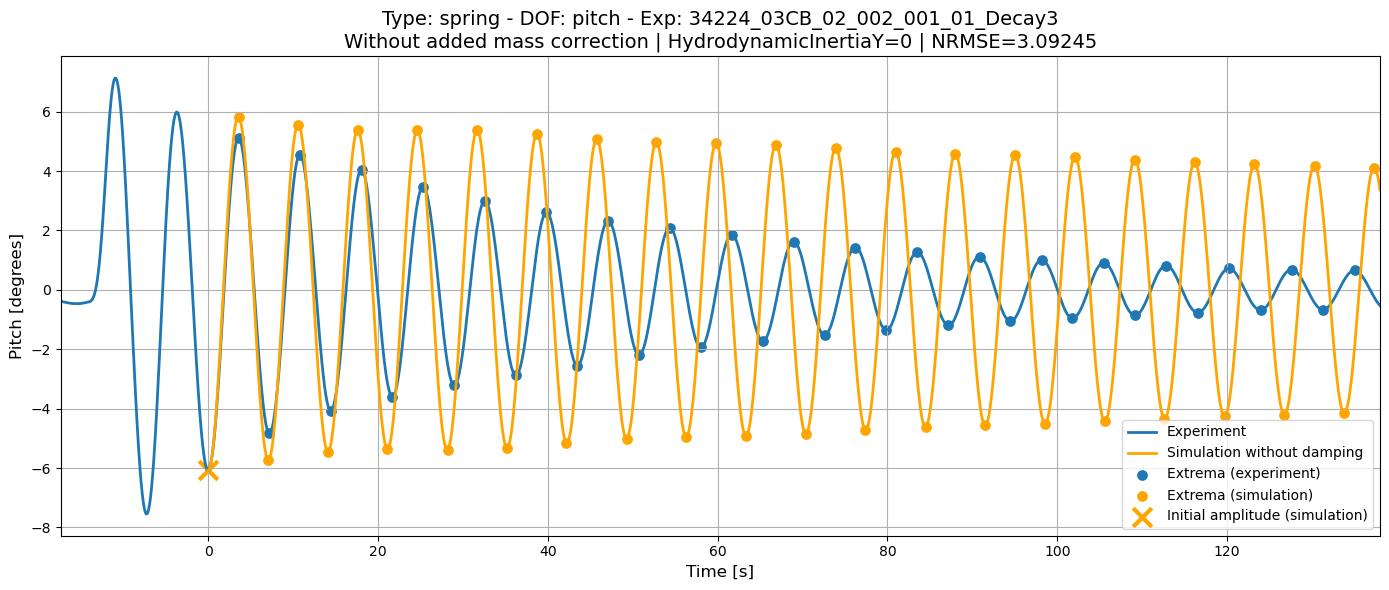

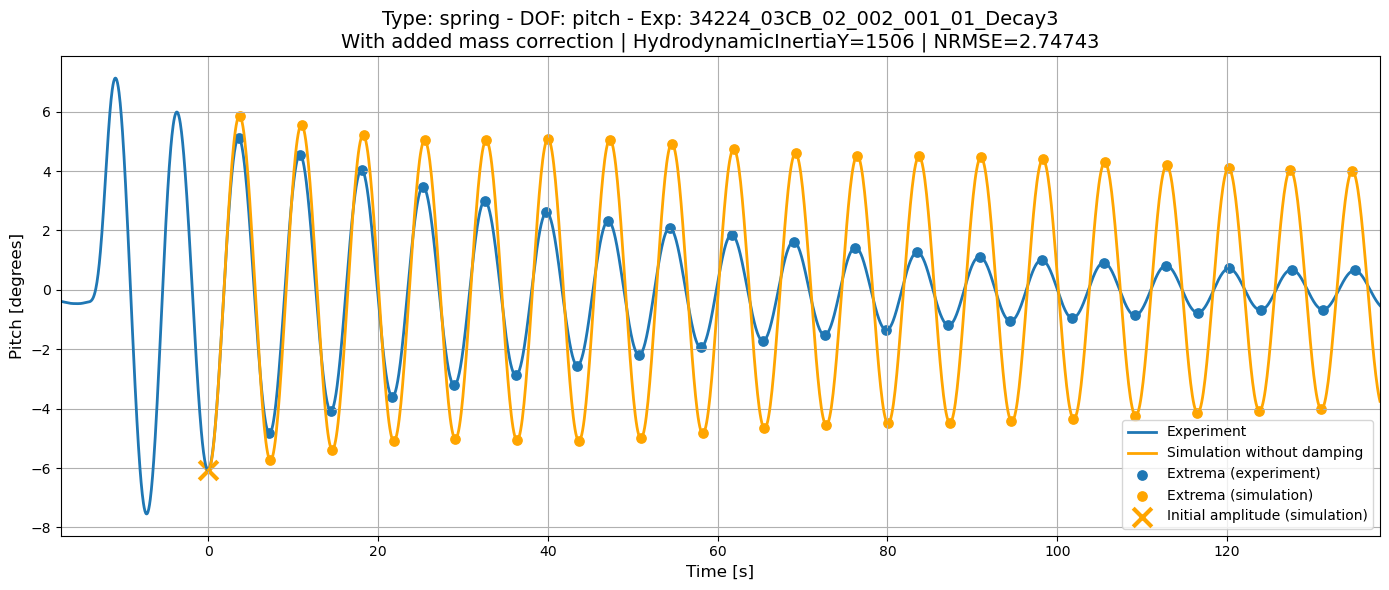

Saved plots:
C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_postprocess\plots_addedmass_compare_pitch_spring\pitch_spring_34224_03CB_02_002_001_01_Decay3_without_added_mass_correction.png
C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_postprocess\plots_addedmass_compare_pitch_spring\pitch_spring_34224_03CB_02_002_001_01_Decay3_with_added_mass_correction.png
Saved summary: C:\Users\verav\Desktop\Studie\Afstuderen\Decay_calibration_postprocess\tables\pitch_spring_addedmass_compare.xlsx


In [40]:
# ============================================================
# 8. Save the two plots and the summary table
# ============================================================
plot_paths = []
for result in results:
    out_path = plot_added_mass_case(result, plots_dir)
    plot_paths.append(out_path)

summary_df["plot_path"] = [str(p) for p in plot_paths]
summary_df["exp_path"] = str(exp_path)
summary_df["model_path"] = str(model_path)
summary_df["initial_pitch_amplitude_A2"] = exp_info["a_A2"]
summary_df.to_excel(summary_excel_path, index=False)

print("Saved plots:")
for p in plot_paths:
    print(p)
print("Saved summary:", summary_excel_path)
